In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [44]:
df = pd.read_csv("../data/Liver.csv", encoding="latin1")
df.head()


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1


In [45]:
df.shape

(30691, 11)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8    ALB Albumin                          30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [47]:
df.columns = df.columns.str.replace("\xa0", "", regex=False).str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4   Alkphos Alkaline Phosphotase          29895 non-null  float64
 5   Sgpt Alamine Aminotransferase         30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8   ALB Albumin                           30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [48]:
df.isna().sum()

Age of the patient                        2
Gender of the patient                   902
Total Bilirubin                         648
Direct Bilirubin                        561
Alkphos Alkaline Phosphotase            796
Sgpt Alamine Aminotransferase           538
Sgot Aspartate Aminotransferase         462
Total Protiens                          463
ALB Albumin                             494
A/G Ratio Albumin and Globulin Ratio    559
Result                                    0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(11323)

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19368 entries, 0 to 30689
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    19367 non-null  float64
 1   Gender of the patient                 18572 non-null  object 
 2   Total Bilirubin                       18811 non-null  float64
 3   Direct Bilirubin                      18878 non-null  float64
 4   Alkphos Alkaline Phosphotase          18674 non-null  float64
 5   Sgpt Alamine Aminotransferase         18909 non-null  float64
 6   Sgot Aspartate Aminotransferase       18975 non-null  float64
 7   Total Protiens                        18998 non-null  float64
 8   ALB Albumin                           18955 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  18932 non-null  float64
 10  Result                                19368 non-null  int64  
dtypes: float64(9), int64

In [52]:
df["Result"].value_counts()

Result
1    13811
2     5557
Name: count, dtype: int64

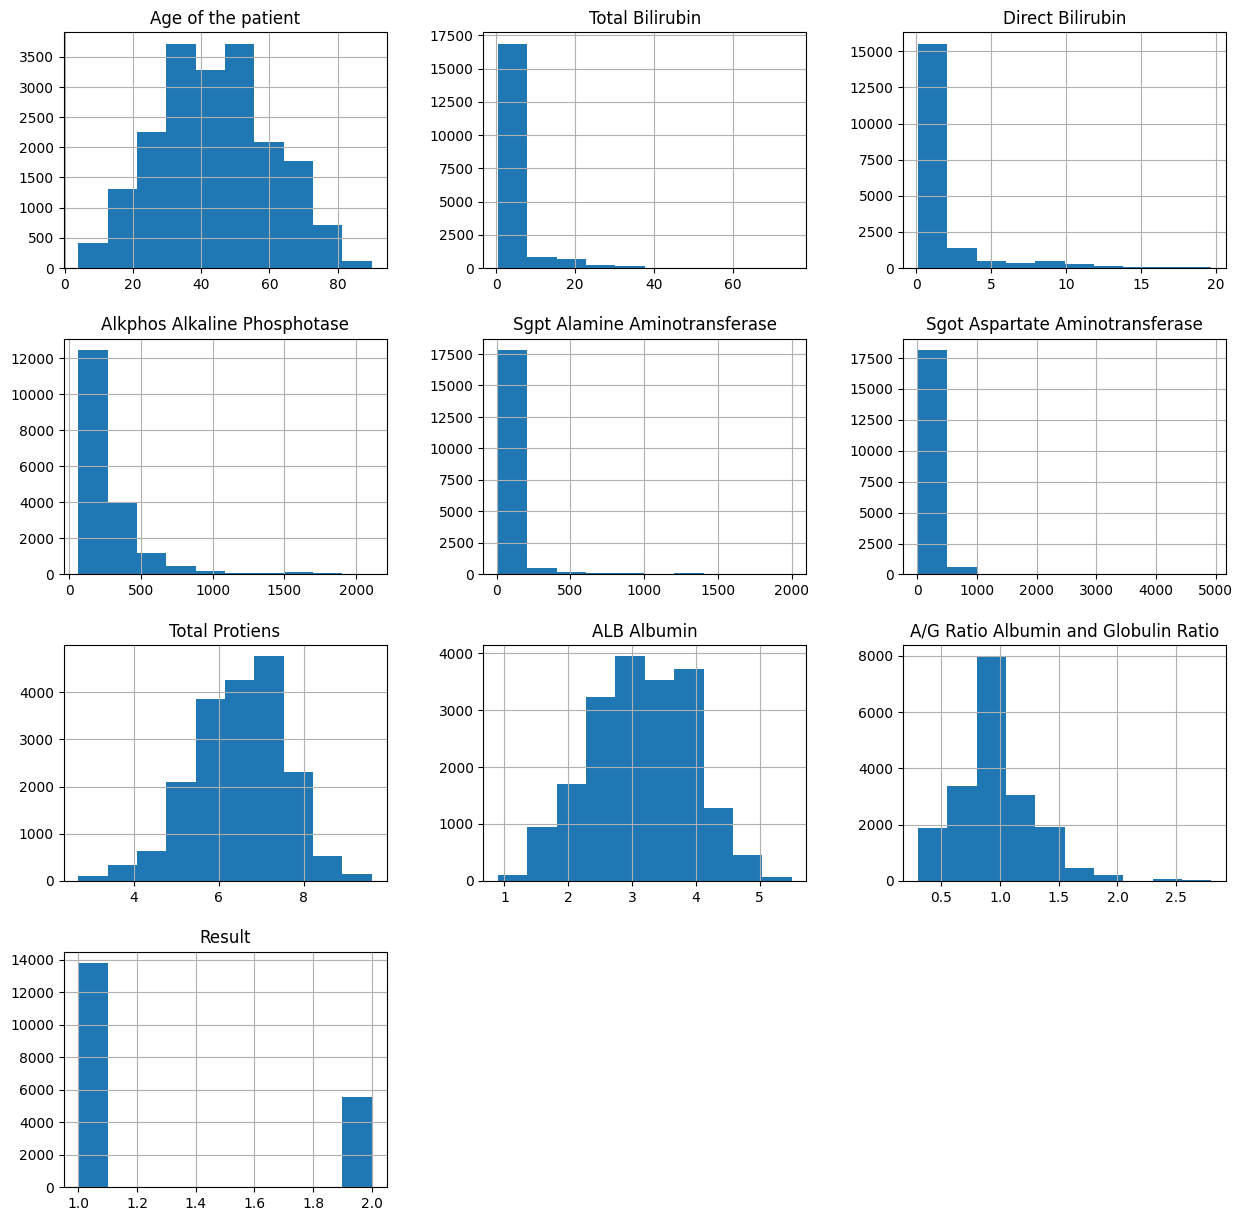

In [53]:
df.hist(figsize=(15,15))
plt.show()

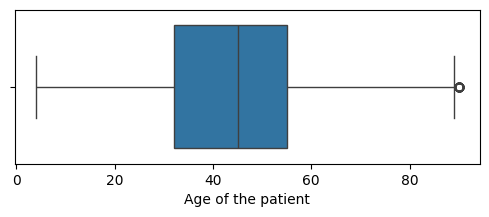

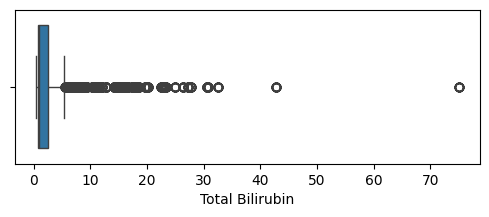

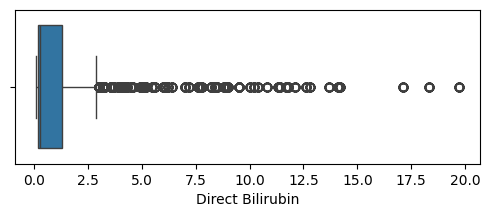

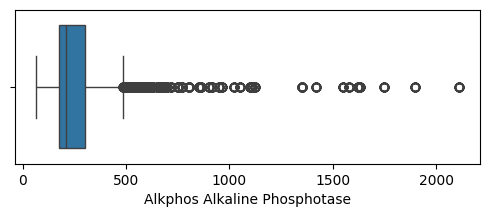

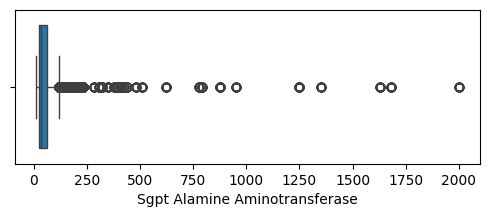

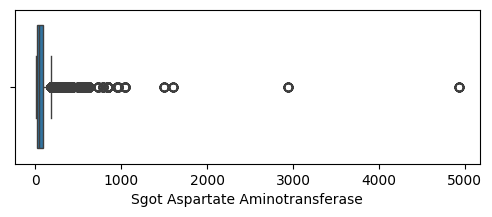

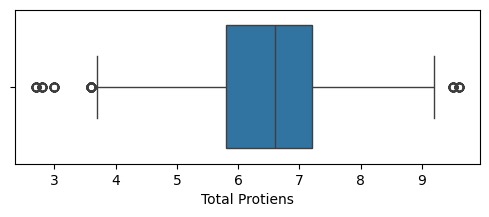

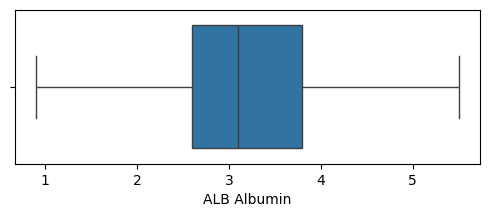

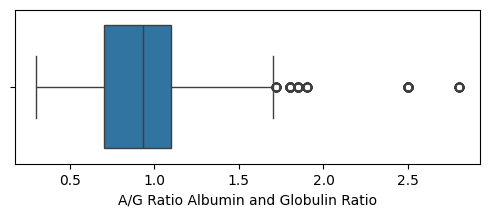

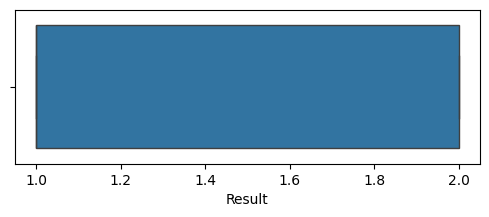

In [55]:
numeric = df.select_dtypes(np.number).columns

for col in numeric:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.show()

In [57]:
from sklearn.impute import SimpleImputer

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

imputer = SimpleImputer(strategy="median")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

cat_cols = ["Gender of the patient"]

imputer = SimpleImputer(strategy="most_frequent")
df[cat_cols] = imputer.fit_transform(df[cat_cols])

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19368 entries, 0 to 30689
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    19368 non-null  float64
 1   Gender of the patient                 19368 non-null  object 
 2   Total Bilirubin                       19368 non-null  float64
 3   Direct Bilirubin                      19368 non-null  float64
 4   Alkphos Alkaline Phosphotase          19368 non-null  float64
 5   Sgpt Alamine Aminotransferase         19368 non-null  float64
 6   Sgot Aspartate Aminotransferase       19368 non-null  float64
 7   Total Protiens                        19368 non-null  float64
 8   ALB Albumin                           19368 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  19368 non-null  float64
 10  Result                                19368 non-null  float64
dtypes: float64(10), obje

In [59]:
df["Result"] = df["Result"].map({
    1: 1,   # Liver Disease
    2: 0    # Healthy
})
df = pd.get_dummies(df, columns=['Gender of the patient'], drop_first=True, dtype=int)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19368 entries, 0 to 30689
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    19368 non-null  float64
 1   Total Bilirubin                       19368 non-null  float64
 2   Direct Bilirubin                      19368 non-null  float64
 3   Alkphos Alkaline Phosphotase          19368 non-null  float64
 4   Sgpt Alamine Aminotransferase         19368 non-null  float64
 5   Sgot Aspartate Aminotransferase       19368 non-null  float64
 6   Total Protiens                        19368 non-null  float64
 7   ALB Albumin                           19368 non-null  float64
 8   A/G Ratio Albumin and Globulin Ratio  19368 non-null  float64
 9   Result                                19368 non-null  int64  
 10  Gender of the patient_Male            19368 non-null  int64  
dtypes: float64(9), int64

<Axes: >

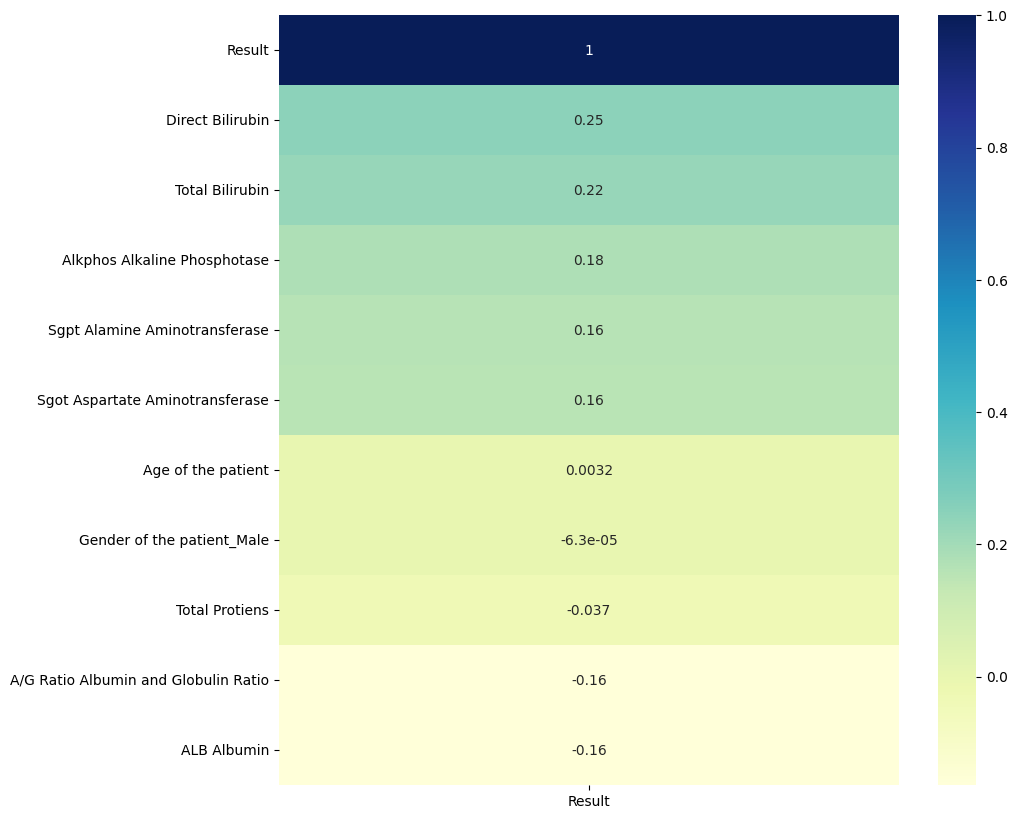

In [62]:
plt.figure(figsize=(10,10))
corr=df.corr()
labeled_corr=corr[['Result']].sort_values('Result', ascending=False)
sns.heatmap(labeled_corr,annot=True,cmap="YlGnBu")

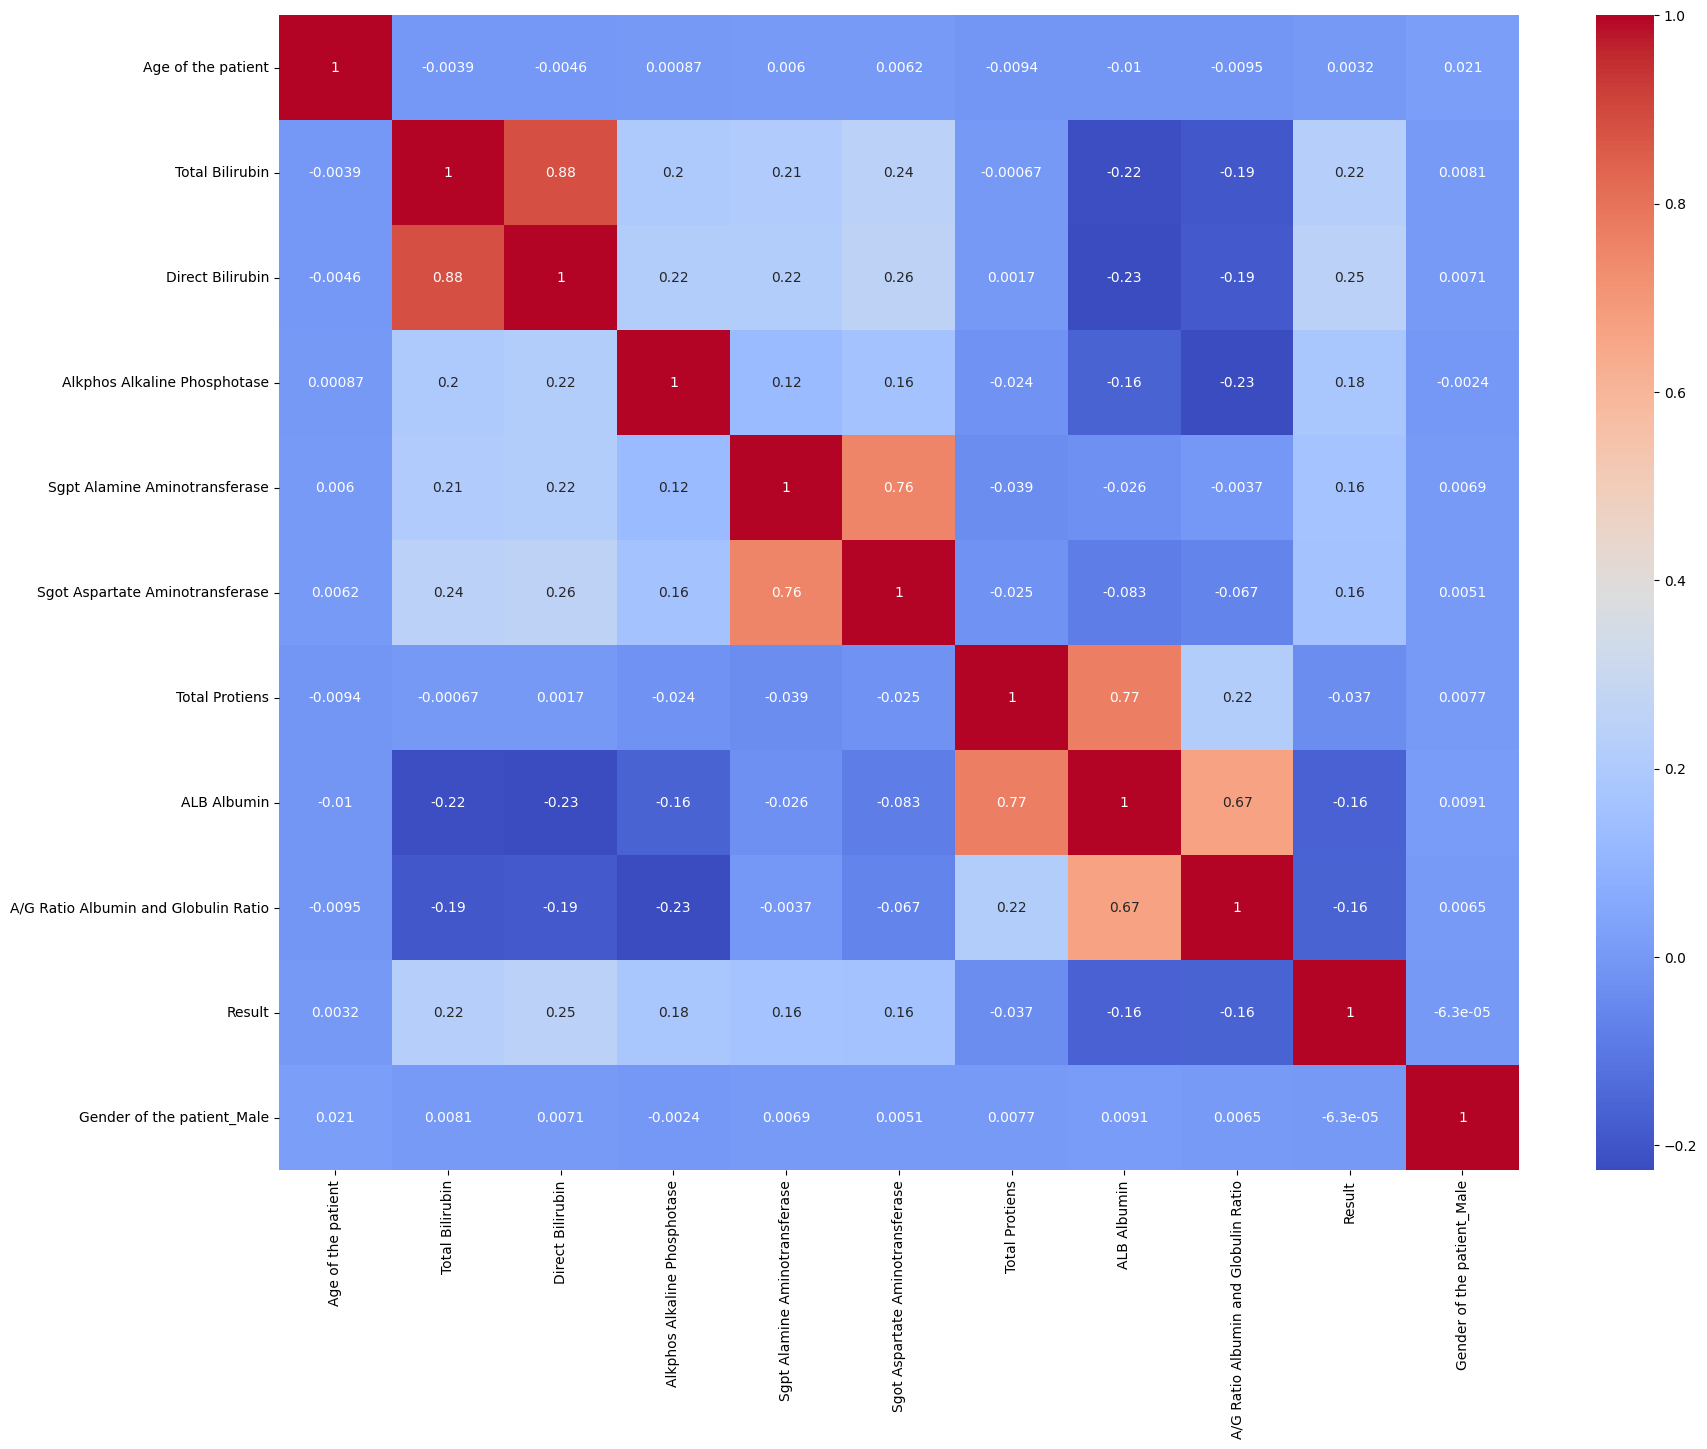

In [64]:
plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
)

plt.show()

In [65]:
df.drop(columns=["Gender of the patient_Male","Age of the patient",], inplace=True)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19368 entries, 0 to 30689
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Total Bilirubin                       19368 non-null  float64
 1   Direct Bilirubin                      19368 non-null  float64
 2   Alkphos Alkaline Phosphotase          19368 non-null  float64
 3   Sgpt Alamine Aminotransferase         19368 non-null  float64
 4   Sgot Aspartate Aminotransferase       19368 non-null  float64
 5   Total Protiens                        19368 non-null  float64
 6   ALB Albumin                           19368 non-null  float64
 7   A/G Ratio Albumin and Globulin Ratio  19368 non-null  float64
 8   Result                                19368 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.5 MB


In [67]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Result"])
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)

y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)



In [74]:
X.to_csv("../data/X.csv", index=False)
y.to_csv("../data/y.csv", index=False)